In [1]:
import ultralytics
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# custom trained model
model = YOLO("Models/best.pt")

In [42]:
img = cv2.imread('Test-Images/img4.jpg')

In [43]:
result = model(img)


0: 384x640 1 License_Plate, 57.1ms
Speed: 4.5ms preprocess, 57.1ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(599.5), np.float64(337.5), np.float64(-0.5))

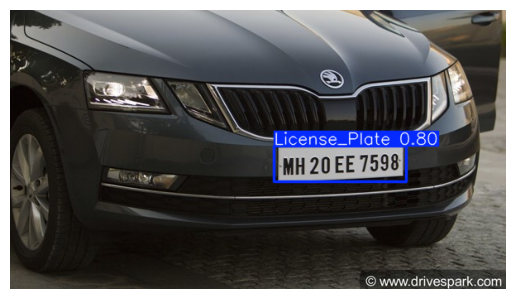

In [44]:
result = result[0]
plt.imshow(result.plot()[:, :, ::-1])
plt.axis("off")

In [11]:
# License Plate detected succesfully

In [12]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    lang="en"
)


Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ak_junior/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ak_junior/.paddlex/official_models/PP-OCRv6_medium_rec`.


In [45]:
for box in result[0].boxes : 
    x1,y1,x2,y2 = box.xyxy[0]
    cropped = img[int(y1):int(y2), int(x1):int(x2)]
    r = ocr.predict(cropped)

In [46]:
text = r[0]["rec_texts"][0]
print(text)

MH20EE 7598
